Total Funds: 5
Total Records in NAV History: 6
Top Performing Fund (by Score):
   amfi_code  mean_return  volatility  sharpe  sortino  max_drawdown  alpha  \
0     118834     0.002199         NaN     NaN      NaN           0.0    NaN   

   beta  score  
0   NaN    NaN  


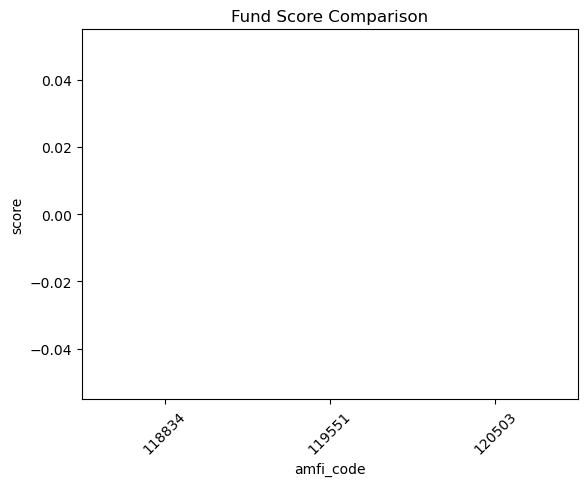

✅ Final summary exported → reports/final_summary.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data/processed")
REPORTS_DIR = Path("../reports")

# Load processed data
nav_history = pd.read_csv(DATA_DIR / "nav_history_clean.csv")
fund_master = pd.read_csv(DATA_DIR / "fund_master_clean.csv")
scorecard = pd.read_csv(REPORTS_DIR / "fund_scorecard.csv")

# -----------------------------
# 1️⃣ Summary Metrics
# -----------------------------
print("Total Funds:", fund_master["fund_name"].nunique())  # ✅ updated
print("Total Records in NAV History:", len(nav_history))
print("Top Performing Fund (by Score):")
print(scorecard.sort_values("score", ascending=False).head(1))

# -----------------------------
# 2️⃣ Visual Summary
# -----------------------------
sns.barplot(data=scorecard, x="amfi_code", y="score", palette="coolwarm")
plt.title("Fund Score Comparison")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 3️⃣ Export Final Report
# -----------------------------
summary = {
    "total_funds": fund_master["fund_name"].nunique(),
    "total_records": len(nav_history),
    "best_fund": scorecard.sort_values("score", ascending=False).iloc[0]["amfi_code"],
    "best_sharpe": scorecard["sharpe"].max(),
    "best_sortino": scorecard["sortino"].max(),
    "lowest_drawdown": scorecard["max_drawdown"].min()
}

pd.DataFrame([summary]).to_csv(REPORTS_DIR / "final_summary.csv", index=False)
print("✅ Final summary exported → reports/final_summary.csv")
